In [3]:
##Zueri wie neu analysis

## Load the data

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

reports = gpd.read_file("../data/raw/Zueri_wie_neu.gpkg")

neighbourhoods = gpd.read_file("../data/raw/Statistische_Quartiere.gpkg",
    layer="stzh.adm_statistische_quartiere_v"
)

# Grosser Titel
## Mittlerer Titel
### Kleiner Titel
Hallo Wie gehts. Das sind vorteile.
1. Aufzählung
2. ABC
   

- Aufzählung ohne
- Nummern
- Bitte

Du bisch mega Nätt.
*Fett* **FETT** ***FETT***


In [4]:
## Inspect the data
## check rows of rep

reports.head()



,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


In [5]:
##check size of reports dataset
reports.shape

(72623, 19)

In [6]:
##check column names of reports
reports.columns

Index(['objectid', 'service_request_id', 'requested_datetime',
       'agency_sent_datetime', 'updated_datetime', 'e', 'n', 'service_code',
       'service_name', 'status', 'userid', 'title', 'detail', 'media_url',
       'interface_used', 'service_notice', 'description', 'url', 'geometry'],
      dtype='object')

In [7]:
##check coordiante reference system
reports.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [8]:
 ##check data types and missing values
reports.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72623 entries, 0 to 72622
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72623 non-null  int32         
 1   service_request_id    72623 non-null  object        
 2   requested_datetime    72623 non-null  datetime64[ms]
 3   agency_sent_datetime  71802 non-null  datetime64[ms]
 4   updated_datetime      72623 non-null  datetime64[ms]
 5   e                     72623 non-null  int32         
 6   n                     72623 non-null  int32         
 7   service_code          72623 non-null  object        
 8   service_name          72623 non-null  object        
 9   status                72623 non-null  object        
 10  userid                72623 non-null  int32         
 11  title                 72623 non-null  object        
 12  detail                72623 non-null  object        
 13  media_ur

In [9]:
##check problem categories
reports["status"].value_counts()

status
fixed - council     63470
external             8959
jurisdiction unk       81
not contactable        69
wish                   22
confirmed              22
Name: count, dtype: int64

In [10]:
## Inspect the data
## check rows of neighbourhoods

neighbourhoods.head()

,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [11]:
##check size of neighbourhoods dataset
neighbourhoods.shape

(34, 7)

In [12]:
##check column names of neighbourhoods
neighbourhoods.columns

Index(['objid', 'objectid', 'qname', 'qnr', 'kname', 'knr', 'geometry'], dtype='object')

In [13]:
##check coordiante reference system
neighbourhoods.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [14]:
 ##check data types and missing values
neighbourhoods.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objid     34 non-null     object  
 1   objectid  34 non-null     int32   
 2   qname     34 non-null     object  
 3   qnr       34 non-null     int32   
 4   kname     34 non-null     object  
 5   knr       34 non-null     int32   
 6   geometry  34 non-null     geometry
dtypes: geometry(1), int32(3), object(3)
memory usage: 1.6+ KB


In [15]:
##data preparation
##checking and converting datetime columns
reports["requested_datetime"] = pd.to_datetime(reports["requested_datetime"])
reports["updated_datetime"] = pd.to_datetime(reports["updated_datetime"])

##creating new time variables
reports["year"] = reports["requested_datetime"].dt.year
reports["month"] = reports["requested_datetime"].dt.month

##select relevat columns for reports
reports_clean = reports[[
    "service_request_id",
    "requested_datetime",
    "service_name",
    "status",
    "geometry",
    "year",
    "month"
]]

In [16]:
##check reports_clean
reports_clean.head()

,service_request_id,requested_datetime,service_name,status,geometry,year,month
0,1,2013-03-14 15:16:15,Strasse/Trottoir/Platz,fixed - council,POINT (2678968 1247548),2013,3
1,2,2013-03-14 15:17:57,Strasse/Trottoir/Platz,fixed - council,POINT (2680746 1249916),2013,3
2,4,2013-03-15 09:14:16,Strasse/Trottoir/Platz,fixed - council,POINT (2684605 1251431),2013,3
3,5,2013-03-15 09:17:15,Strasse/Trottoir/Platz,fixed - council,POINT (2681754 1250376),2013,3
4,6,2013-03-15 10:36:53,Abfall/Sammelstelle,fixed - council,POINT (2683094 1247762),2013,3


In [17]:
reports_clean.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72623 entries, 0 to 72622
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   service_request_id  72623 non-null  object        
 1   requested_datetime  72623 non-null  datetime64[ms]
 2   service_name        72623 non-null  object        
 3   status              72623 non-null  object        
 4   geometry            72623 non-null  geometry      
 5   year                72623 non-null  int32         
 6   month               72623 non-null  int32         
dtypes: datetime64[ms](1), geometry(1), int32(2), object(3)
memory usage: 3.3+ MB


In [18]:
## select relevant columns for neighbourhoods
neighbourhoods_clean = neighbourhoods[[
    "qname",
    "kname",
    "geometry"
]]

In [19]:
##check neighbourhoods_clean
neighbourhoods_clean.head()

,qname,kname,geometry
0,Alt-Wiedikon,Kreis 3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,Witikon,Kreis 7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,Langstrasse,Kreis 4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,Escher Wyss,Kreis 5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,Enge,Kreis 2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [20]:
neighbourhoods_clean.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   qname     34 non-null     object  
 1   kname     34 non-null     object  
 2   geometry  34 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 948.0+ bytes


In [21]:
##spatial analysis
##a spatial join is performed to assign each report to a statistical neighbourhood
reports_with_neighbourhoods = gpd.sjoin(
    reports_clean,
    neighbourhoods_clean,
    how="left",
    predicate="within"
)

In [22]:
reports_with_neighbourhoods.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 72623 entries, 0 to 72622
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   service_request_id  72623 non-null  object        
 1   requested_datetime  72623 non-null  datetime64[ms]
 2   service_name        72623 non-null  object        
 3   status              72623 non-null  object        
 4   geometry            72623 non-null  geometry      
 5   year                72623 non-null  int32         
 6   month               72623 non-null  int32         
 7   index_right         72623 non-null  int64         
 8   qname               72623 non-null  object        
 9   kname               72623 non-null  object        
dtypes: datetime64[ms](1), geometry(1), int32(2), int64(1), object(5)
memory usage: 5.5+ MB


In [40]:
reports_with_neighbourhoods.head()

,service_request_id,requested_datetime,service_name,status,geometry,year,month,index_right,qname,kname
0,1,2013-03-14 15:16:15,Strasse/Trottoir/Platz,fixed - council,POINT (2678968 1247548),2013,3,16,Albisrieden,Kreis 9
1,2,2013-03-14 15:17:57,Strasse/Trottoir/Platz,fixed - council,POINT (2680746 1249916),2013,3,20,Höngg,Kreis 10
2,4,2013-03-15 09:14:16,Strasse/Trottoir/Platz,fixed - council,POINT (2684605 1251431),2013,3,33,Saatlen,Kreis 12
3,5,2013-03-15 09:17:15,Strasse/Trottoir/Platz,fixed - council,POINT (2681754 1250376),2013,3,21,Wipkingen,Kreis 10
4,6,2013-03-15 10:36:53,Abfall/Sammelstelle,fixed - council,POINT (2683094 1247762),2013,3,15,City,Kreis 1


In [49]:
##analysis
##reports per neighbourhood
reports_with_neighbourhoods["qname"].value_counts()

qname
Langstrasse             6185
Sihlfeld                5235
Altstetten              4094
Unterstrass             3594
Wipkingen               3304
Höngg                   3090
Oerlikon                2985
Hard                    2855
Wollishofen             2837
Enge                    2756
Seebach                 2622
Alt-Wiedikon            2502
Affoltern               2419
Gewerbeschule           2230
Albisrieden             2048
Hottingen               1948
City                    1741
Escher Wyss             1562
Werd                    1529
Oberstrass              1516
Rathaus                 1457
Hochschulen             1415
Friesenberg             1415
Hirslanden              1380
Seefeld                 1280
Fluntern                1254
Schwamendingen-Mitte    1234
Witikon                 1132
Lindenhof               1125
Mühlebach                908
Hirzenbach               854
Weinegg                  809
Saatlen                  676
Leimbach                 632
Name: co

In [42]:
##most common problem categories
reports_clean["service_name"].value_counts()

service_name
Abfall/Sammelstelle          27339
Signalisation/Lichtsignal    10975
Strasse/Trottoir/Platz        9870
Grünflächen/Spielplätze       7238
Beleuchtung/Uhren             5407
Allgemein                     3969
Graffiti                      3759
VBZ/ÖV                        1882
Brunnen/Hydranten             1289
Schädlinge                     895
Name: count, dtype: int64

In [43]:
##certain problems concentrated in specific neighbourhoods
reports_with_neighbourhoods.groupby(["qname", "service_name"]).size()

qname        service_name             
Affoltern    Abfall/Sammelstelle          779
             Allgemein                    109
             Beleuchtung/Uhren            246
             Brunnen/Hydranten             30
             Graffiti                     133
                                         ... 
Wollishofen  Grünflächen/Spielplätze      371
             Schädlinge                    95
             Signalisation/Lichtsignal    411
             Strasse/Trottoir/Platz       386
             VBZ/ÖV                        51
Length: 340, dtype: int64

In [44]:
##problems over time
reports_clean.groupby("month").size()

month
1     5161
2     4753
3     5619
4     6601
5     6483
6     6842
7     7291
8     7293
9     6505
10    6102
11    5392
12    4581
dtype: int64

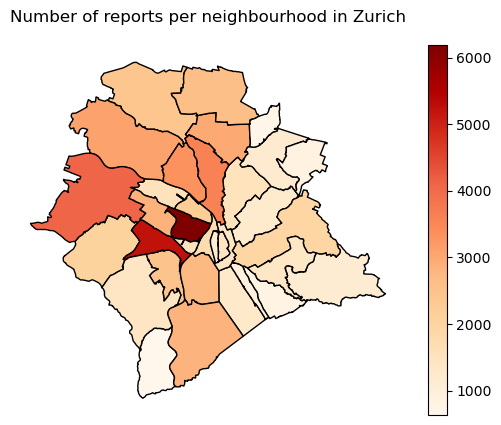

In [55]:
##reports per neighbourhoods
reports_per_neighbourhood = (
    reports_with_neighbourhoods
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
)

neighbourhoods_merged = neighbourhoods.merge(
    reports_per_neighbourhood,
    on="qname",
    how="left"
)


neighbourhoods_merged.plot(
    column="report_count",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    missing_kwds={
        "color": "lightgrey",
        "label": "No reports"
         }
)

plt.title("Number of reports per neighbourhood in Zurich")
plt.axis("off")
plt.show()